In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scirpy as ir 
import muon as mu

In [2]:
sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor="white")

scanpy==1.10.2 anndata==0.10.8 umap==0.5.6 numpy==2.0.2 scipy==1.14.0 pandas==2.2.2 scikit-learn==1.5.1 statsmodels==0.14.2 igraph==0.11.5 pynndescent==0.5.13


In [25]:
mdata = mu.read("/Users/jerryaaaaaa/tcr_model_2.h5mu")

In [51]:
mdata["gex"].obs

,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,clone_id,clonal_dynamic_label,clonal_dynamic,expansion_fold,...,beta_cdr3_aa,alpha_cdr3_len,beta_cdr3_len,clonal_abundance,enriched_tier,reactivity_score,tcr_sig_score,bystander_score,tumor_reactivity,clonal_reactivity
AAACCTGAGAATGTTG-1,7719,7714,59153.0,276.0,0.466587,0,0,1.0,Enriched,18.141,...,ASSVEPQLAGRGDTQY,16,16,2879,Tier_3,0.188347,0.118751,1.007417,0.141675,0.287487
AAACCTGAGGTAGCTG-1,3443,3443,9105.0,33.0,0.362438,1,0,1.0,Enriched,18.141,...,ASSVEPQLAGRGDTQY,16,16,2879,Tier_3,1.477983,1.351218,-0.462463,0.487399,0.287487
AAACCTGAGTAGATGT-1,3740,3740,11302.0,92.0,0.814015,4,1,1.0,Enriched,4.414,...,ASSYYRPTGPYEQY,9,14,219,Tier_4,1.305020,1.084595,-0.271022,0.424012,0.398309
AAACCTGAGTGGAGTC-1,3287,3286,9576.0,55.0,0.574353,1,0,1.0,Enriched,18.141,...,ASSVEPQLAGRGDTQY,16,16,2879,Tier_3,1.320357,1.325374,-0.098237,0.414425,0.287487
AAACCTGCAGACAAGC-1,3016,3016,8776.0,100.0,1.139471,1,0,1.0,Enriched,18.141,...,ASSVEPQLAGRGDTQY,16,16,2879,Tier_3,1.487265,1.283735,-0.325525,0.454714,0.287487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACATCGACGC-1,1980,1980,4300.0,75.0,1.744186,1,0,1.0,Enriched,18.141,...,ASSVEPQLAGRGDTQY,16,16,2879,Tier_3,1.612368,1.629227,0.201726,0.376010,0.287487
TTTGTCAGTTGGAGGT-1,5410,5409,26259.0,232.0,0.883507,0,0,1.0,Enriched,18.141,...,ASSVEPQLAGRGDTQY,16,16,2879,Tier_3,0.691086,0.494680,0.730447,0.201953,0.287487
TTTGTCATCACAACGT-1,6239,6238,30520.0,238.0,0.779817,3,111,1.0,Enriched,104.145,...,ASTLLRGEQF,14,10,12,Tier_2,0.928035,1.190748,0.151243,0.354496,0.296096
TTTGTCATCCAAATGC-1,2543,2542,4771.0,110.0,2.305596,3,3,1.0,Enriched,164.062,...,ASSARGTKNIQY,10,12,172,Tier_2,0.913199,1.141949,-0.188439,0.414624,0.270000


In [27]:
tcr_signaling_genes = ["CXCL13", "ENTPD1", "PDCD1", "TOX", "LAG3", "TIGIT", "HAVCR2", "CTLA4", "ITGAE",
                       "GZMB", "GZMH", "PRF1", "GNLY", "NKG7", "IFNG", "CCL4", "CCL5",
                       "CD69", "NR4A1", "NR4A2", "NR4A3", "EGR1", "EGR2", "FOS", "JUN", "DUSP2", "DUSP4", "IL2RA", "TNFRSF9"
                       ]
bystander_genes = ["MKI67", "TOP2A", "STMN1", "TUBA1B", "HMGB2", "PCNA"]


In [28]:
sc.tl.score_genes(mdata["gex"], tcr_signaling_genes, score_name="tcr_sig_score")
sc.tl.score_genes(mdata["gex"], bystander_genes, score_name="bystander_score")

computing score 'tcr_sig_score'
    finished: added
    'tcr_sig_score', score of gene set (adata.obs).
    401 total control genes are used. (0:00:00)
computing score 'bystander_score'
    finished: added
    'bystander_score', score of gene set (adata.obs).
    149 total control genes are used. (0:00:00)


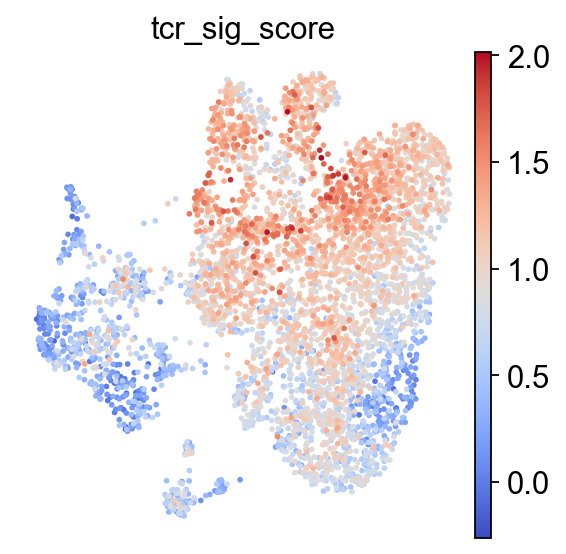

In [29]:
sc.pl.umap(mdata["gex"], color="tcr_sig_score", frameon=False, cmap="coolwarm")

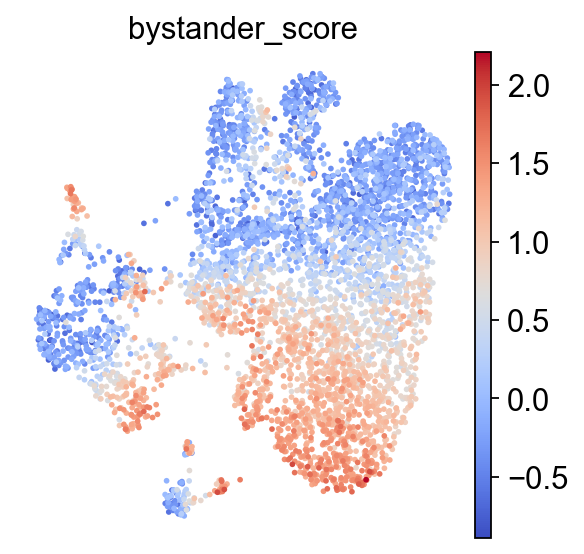

In [30]:
sc.pl.umap(mdata["gex"], color="bystander_score", frameon=False, cmap="coolwarm")

In [18]:
from scipy.special import expit

P(reactive) = P(tcr) * P(non-bystander)

In [31]:
tcr = expit(mdata["gex"].obs["tcr_sig_score"])
bystander = expit(mdata["gex"].obs["bystander_score"])

mdata["gex"].obs["tumor_reactivity"] = tcr * (1 - bystander)

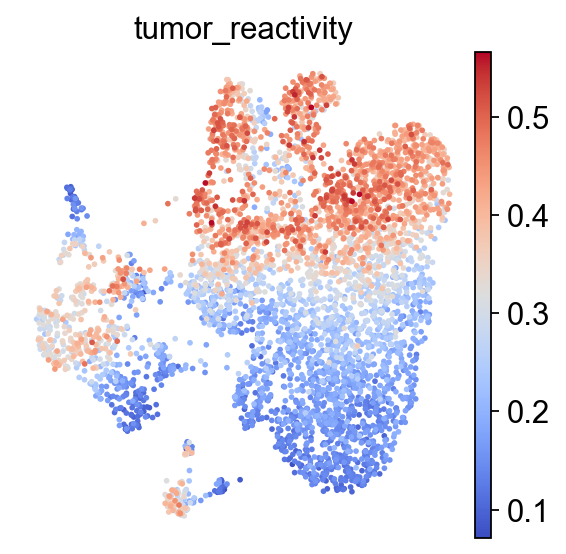

In [32]:
sc.pl.umap(mdata["gex"], color="tumor_reactivity", frameon=False, cmap="coolwarm")

In [33]:
mdata["gex"].obs["clonal_reactivity"] = (
    mdata["gex"].obs.groupby("clone_id")["tumor_reactivity"]
    .transform("mean")
)

/var/folders/s3/tmfhtnzx1g34x3_f84h69dh40000gn/T/ipykernel_51545/3658817788.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mdata["gex"].obs.groupby("clone_id")["tumor_reactivity"]


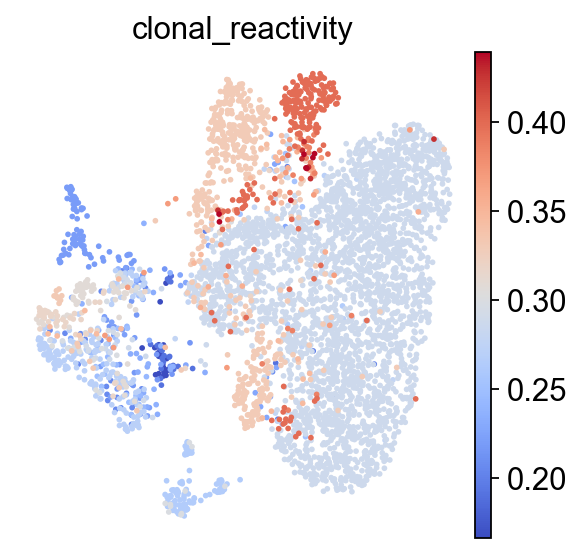

In [43]:
sc.pl.umap(mdata["gex"], color="clonal_reactivity", frameon=False, cmap="coolwarm")

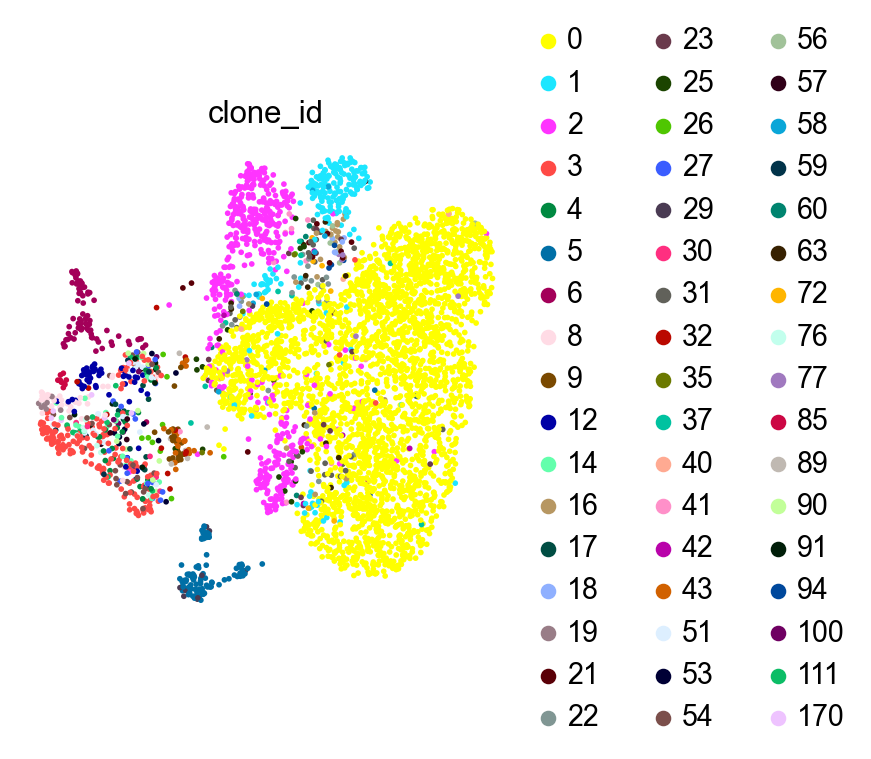

In [35]:
sc.pl.umap(mdata["gex"], color="clone_id", frameon=False)

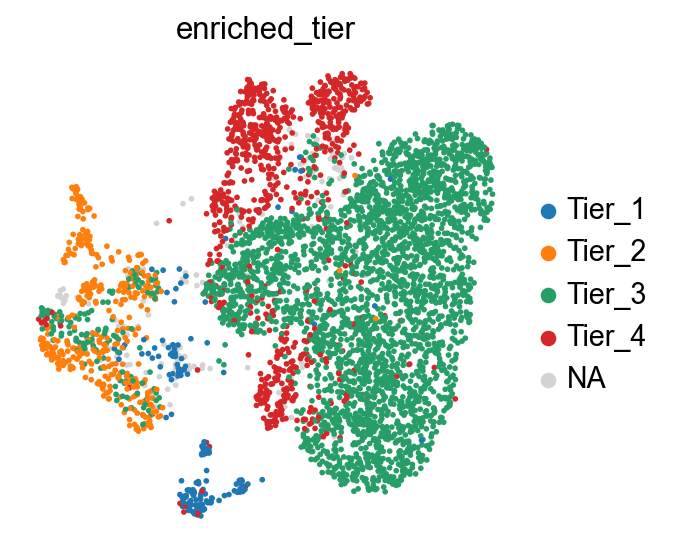

In [40]:
sc.pl.umap(mdata["gex"], color="enriched_tier", frameon=False)

In [47]:
clone_scores = (
    mdata["gex"].obs.groupby("clone_id")["tumor_reactivity"]
    .mean()    
    .reset_index(name="clonal_reactivity")
)

/var/folders/s3/tmfhtnzx1g34x3_f84h69dh40000gn/T/ipykernel_51545/949836689.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mdata["gex"].obs.groupby("clone_id")["tumor_reactivity"]


In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

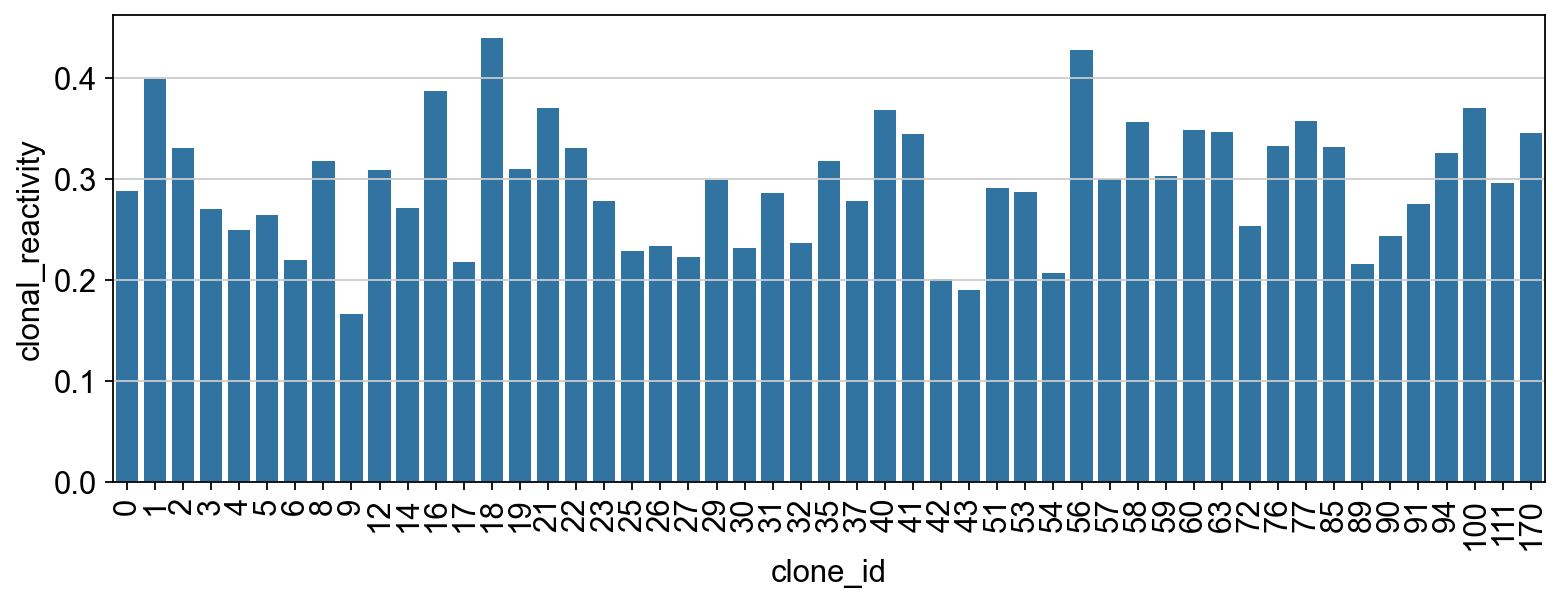

In [50]:
plt.figure(figsize=(10, 4))

sns.barplot(
    data=clone_scores,
    x="clone_id",
    y="clonal_reactivity"
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [53]:
cdr3_df = (
    mdata["gex"].obs
    .groupby("clone_id")
    .agg({
        "alpha_cdr3_aa": "first",
        "beta_cdr3_aa": "first"
    })
    .reset_index()
)

/var/folders/s3/tmfhtnzx1g34x3_f84h69dh40000gn/T/ipykernel_51545/790081890.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("clone_id")


In [55]:
clone_df = (
    mdata["gex"].obs
    .groupby("clone_id")
    .agg({
        "tumor_reactivity": "mean",
        "tcr_sig_score": "mean",
        "bystander_score": "mean",
        "clonal_abundance": "size"
    })
    .reset_index()
)

/var/folders/s3/tmfhtnzx1g34x3_f84h69dh40000gn/T/ipykernel_51545/3907726390.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("clone_id")


In [56]:
clone_df = clone_df.merge(cdr3_df, on="clone_id", how="left")

In [60]:
clone_df.to_csv("/Users/jerryaaaaaa/260514_scTCR_clonal_info.csv")

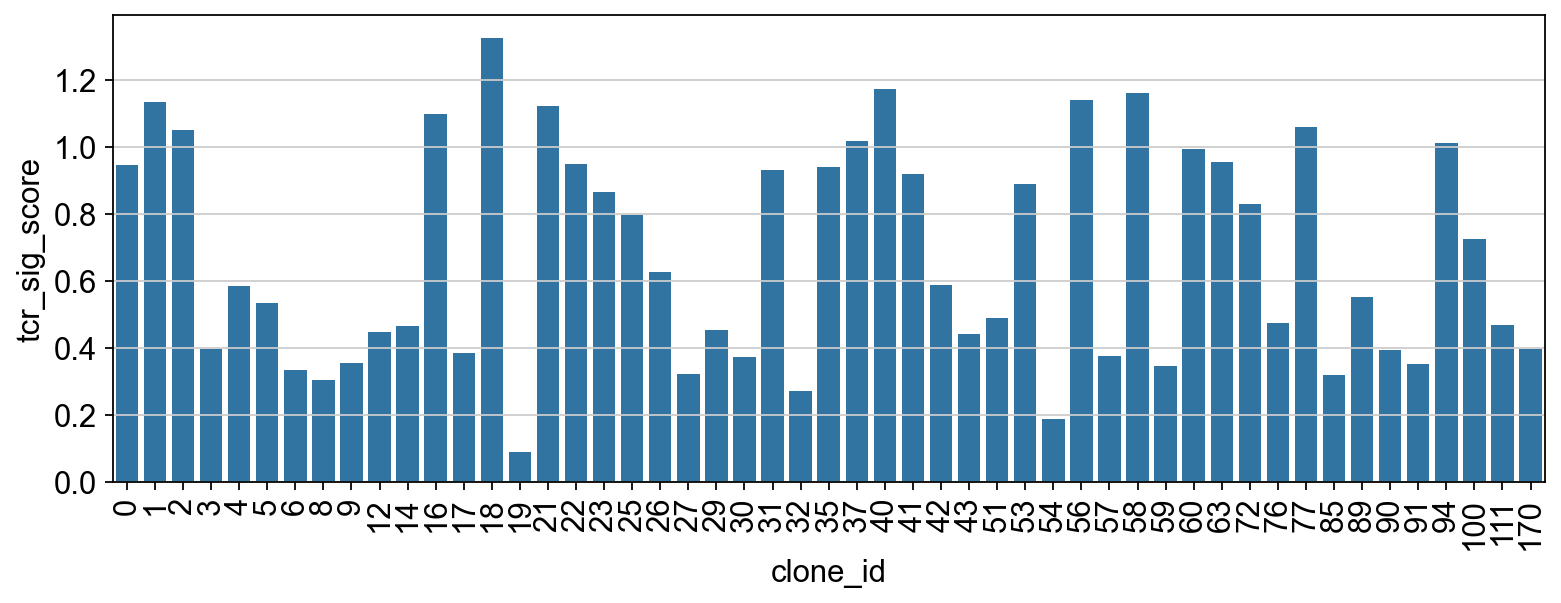

In [58]:
plt.figure(figsize=(10, 4))

sns.barplot(
    data=clone_df,
    x="clone_id",
    y="tcr_sig_score"
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

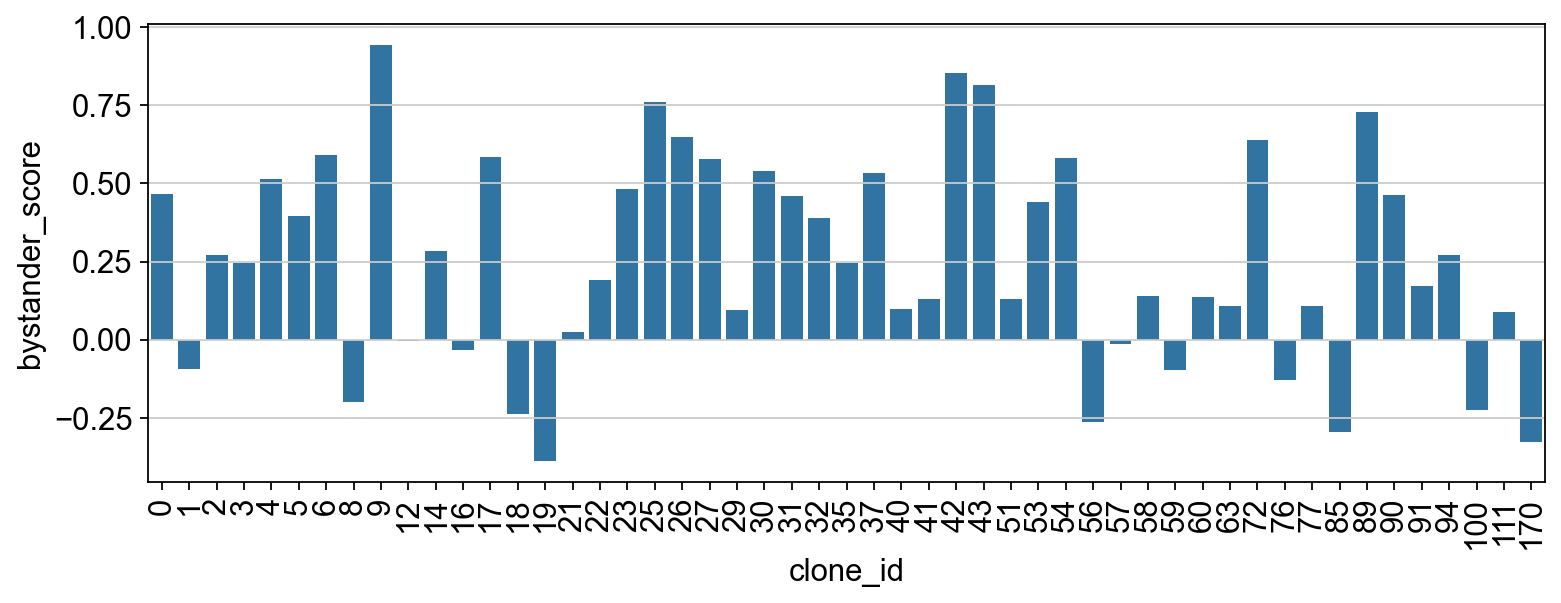

In [59]:
plt.figure(figsize=(10, 4))

sns.barplot(
    data=clone_df,
    x="clone_id",
    y="bystander_score"
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()